# Fusion Model Training

This notebook trains a fusion model that combines predictions from three modalities:
- **Text**: DistilBERT fine-tuned on GoEmotions
- **Audio**: CNN trained on speech features
- **Face**: ViT trained on facial expressions

The fusion model takes probability vectors (6-class) from each modality and learns to combine them into a final 6-class prediction.

**6 Emotion Classes:** Positive, Neutral, Stress, Anxiety, Negative, Depression

In [1]:
!pip install tensorflow pandas numpy scikit-learn matplotlib seaborn datasets -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

In [3]:
CLASS_NAMES = ["Positive", "Neutral", "Stress", "Anxiety", "Negative", "Depression"]
NUM_CLASSES = len(CLASS_NAMES)
NUM_MODALITIES = 3
INPUT_DIM = NUM_CLASSES * NUM_MODALITIES  # 18 features

print(f"Number of classes: {NUM_CLASSES}")
print(f"Input feature dimension: {INPUT_DIM}")

Number of classes: 6
Input feature dimension: 18


## Data Generation

Since no complete multimodal dataset exists with all three modalities aligned, we simulate training data using:
- **GoEmotions** text dataset for ground truth labels
- Synthetic audio and face probability vectors with varying noise levels
- Controlled scenarios: all agree, two agree, only one informative, etc.

In [4]:
print("Loading GoEmotions dataset...")
from datasets import load_dataset
ds = load_dataset("google-research-datasets/go_emotions")
train_ds = ds["train"]
test_ds = ds["test"]
print(f"Train set size: {len(train_ds)}")
print(f"Test set size: {len(test_ds)}")

Loading GoEmotions dataset...


Train set size: 43410
Test set size: 5427


In [5]:
id2label_28 = {
    0: 'admiration', 1: 'amusement', 2: 'anger', 3: 'annoyance',
    4: 'approval', 5: 'caring', 6: 'confusion', 7: 'curiosity',
    8: 'desire', 9: 'disappointment', 10: 'disapproval', 11: 'disgust',
    12: 'embarrassment', 13: 'excitement', 14: 'fear', 15: 'gratitude',
    16: 'grief', 17: 'joy', 18: 'love', 19: 'nervousness',
    20: 'optimism', 21: 'pride', 22: 'realization', 23: 'relief',
    24: 'remorse', 25: 'sadness', 26: 'surprise', 27: 'neutral'
}

final_map = {
    'admiration': 0, 'amusement': 0, 'approval': 0, 'caring': 0,
    'desire': 0, 'excitement': 0, 'gratitude': 0, 'joy': 0, 'love': 0,
    'optimism': 0, 'pride': 0, 'relief': 0,
    'curiosity': 1, 'realization': 1, 'surprise': 1, 'neutral': 1,
    'anger': 2, 'annoyance': 2, 'disapproval': 2, 'confusion': 2,
    'fear': 3, 'nervousness': 3,
    'disappointment': 4, 'disgust': 4, 'embarrassment': 4, 'remorse': 4,
    'grief': 5, 'sadness': 5
}

def convert_label(example):
    labels = example['labels']
    if len(labels) == 0:
        example['label_6'] = 1
    else:
        first = labels[0]
        example['label_6'] = final_map[id2label_28[first]]
    return example

train_ds = train_ds.map(convert_label)
test_ds = test_ds.map(convert_label)

In [6]:
def to_one_hot(label, num_classes):
    vec = np.zeros(num_classes)
    vec[label] = 1.0
    return vec

y_train = np.array([to_one_hot(l, NUM_CLASSES) for l in train_ds['label_6']])
y_test = np.array([to_one_hot(l, NUM_CLASSES) for l in test_ds['label_6']])

print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

y_train shape: (43410, 6)
y_test shape: (5427, 6)


In [7]:
EPS = 1e-8  # prevent division by zero

def generate_synthetic_modality_probs(true_label, noise_level=0.3, uncertainty=0.1):
    probs = np.ones(NUM_CLASSES) * uncertainty / (NUM_CLASSES - 1)
    probs[true_label] = 1.0 - uncertainty
    probs += np.random.normal(0, noise_level, NUM_CLASSES)
    probs = np.clip(probs, 0, 1)
    return probs / (probs.sum() + EPS)

def generate_training_sample(true_label, scenario='agree'):
    if scenario == 'agree':
        tp = generate_synthetic_modality_probs(true_label, 0.15)
        ap = generate_synthetic_modality_probs(true_label, 0.20)
        fp = generate_synthetic_modality_probs(true_label, 0.25)
    elif scenario == 'text_dominant':
        tp = generate_synthetic_modality_probs(true_label, 0.1)
        ap = generate_synthetic_modality_probs(true_label, 0.45)
        fp = generate_synthetic_modality_probs(true_label, 0.45)
    elif scenario == 'conflict':
        wrong = (true_label + np.random.randint(1, NUM_CLASSES)) % NUM_CLASSES
        tp = generate_synthetic_modality_probs(true_label, 0.1)
        ap = generate_synthetic_modality_probs(wrong, 0.15)
        fp = generate_synthetic_modality_probs(wrong, 0.15)
    elif scenario == 'uncertain':
        tp = generate_synthetic_modality_probs(true_label, 0.4, 0.5)
        ap = generate_synthetic_modality_probs(true_label, 0.4, 0.5)
        fp = generate_synthetic_modality_probs(true_label, 0.4, 0.5)
    else:
        raise ValueError(f'Unknown scenario: {scenario}')
    return np.concatenate([tp, ap, fp])

In [8]:
SEED = 42
np.random.seed(SEED)

scenarios = ['agree', 'agree', 'text_dominant', 'conflict', 'uncertain']
scenario_weights = [0.4, 0.3, 0.15, 0.1, 0.05]

def generate_dataset(labels, size):
    X_list = []
    for i in range(size):
        s = np.random.choice(scenarios, p=scenario_weights)
        X_list.append(generate_training_sample(labels[i], s))
    return np.array(X_list)

X_train = generate_dataset(train_ds['label_6'], len(train_ds))
X_test = generate_dataset(test_ds['label_6'], len(test_ds))

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (43410, 18)
X_test shape: (5427, 18)
y_train shape: (43410, 6)
y_test shape: (5427, 6)


## Model Architecture

A multi-layer perceptron that learns to combine modality probability vectors:
- Input: 18 features (6 probs x 3 modalities: text, audio, face)
- Hidden layers with BatchNorm, Dropout, and L2 regularization
- Output: 6-class softmax

In [9]:
def build_fusion_model(input_dim=INPUT_DIM, num_classes=NUM_CLASSES):
    inputs = Input(shape=(input_dim,), name='modality_probs')
    x = Dense(64, activation='relu', kernel_regularizer=l2(1e-5))(inputs)
    x = BatchNormalization()(x)
    x = Dense(32, activation='relu', kernel_regularizer=l2(1e-5))(x)
    x = BatchNormalization()(x)
    outputs = Dense(num_classes, name='emotion_logits')(x)
    model = Model(inputs=inputs, outputs=outputs, name='fusion_model')
    return model

model = build_fusion_model()
model.summary()


Model: "fusion_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ modality_probs (InputLayer)     │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ emotion_logits (Dense)          │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,878 (15.15 KB)

 Trainable params: 3,686 (14.40 KB)

 Non-trainable params: 192 (768.00 B)

In [10]:
model.compile(
    optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
    loss=CategoricalCrossentropy(from_logits=True, label_smoothing=0.05),
    metrics=['accuracy']
)
print('Model compiled successfully')


Model compiled successfully


In [11]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint(filepath='../models/fusion_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

In [12]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100


  1/679 ━━━━━━━━━━━━━━━━━━━━ 23:24 2s/step - accuracy: 0.0781 - loss: 2.4019

 17/679 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2860 - loss: 1.8835  

 29/679 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4149 - loss: 1.6397

 43/679 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5110 - loss: 1.4441

...


Epoch 32: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.



Epoch 32: val_accuracy did not improve from 0.98231


679/679 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9893 - loss: 0.2718 - val_accuracy: 0.9808 - val_loss: 0.2962 - learning_rate: 1.2500e-04


Epoch 32: early stopping


Restoring model weights from the end of the best epoch: 17.


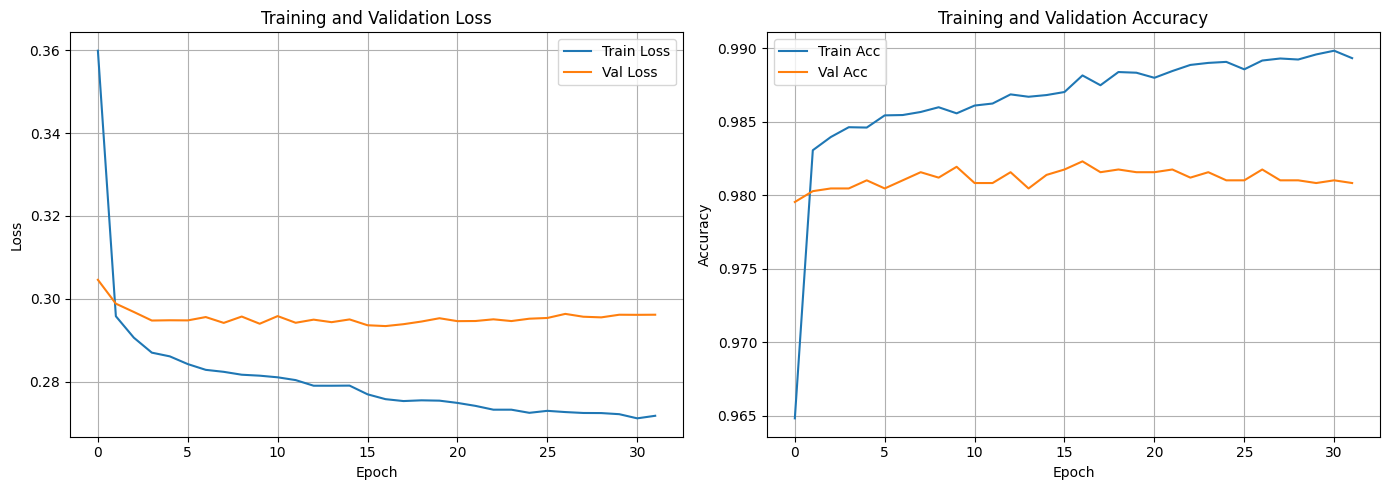

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)
ax2.plot(history.history['accuracy'], label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.savefig('../models/fusion_training_history.png', dpi=150)
plt.show()

In [14]:
y_pred_logits = model.predict(X_test, verbose=0)
# Apply softmax to convert logits to probabilities for metrics
y_pred_probs = np.exp(y_pred_logits) / np.sum(np.exp(y_pred_logits), axis=1, keepdims=True)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

metrics = {}
metrics['Accuracy'] = round(accuracy_score(y_true, y_pred), 4)
metrics['Precision'] = round(precision_score(y_true, y_pred, average='weighted'), 4)
metrics['Recall'] = round(recall_score(y_true, y_pred, average='weighted'), 4)
metrics['F1-Score'] = round(f1_score(y_true, y_pred, average='weighted'), 4)

pd.DataFrame([metrics])


,Accuracy,Precision,Recall,F1-Score
0,0.9823,0.9823,0.9823,0.9823


In [15]:
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

              precision    recall  f1-score   support

    Positive     0.9869    0.9878    0.9873      2054
     Neutral     0.9815    0.9907    0.9861      2040
      Stress     0.9785    0.9739    0.9762       842
     Anxiety     0.9545    0.9333    0.9438        90
    Negative     0.9855    0.9443    0.9644       287
  Depression     0.9550    0.9298    0.9422       114

    accuracy                         0.9823      5427
   macro avg     0.9736    0.9600    0.9667      5427
weighted avg     0.9823    0.9823    0.9823      5427



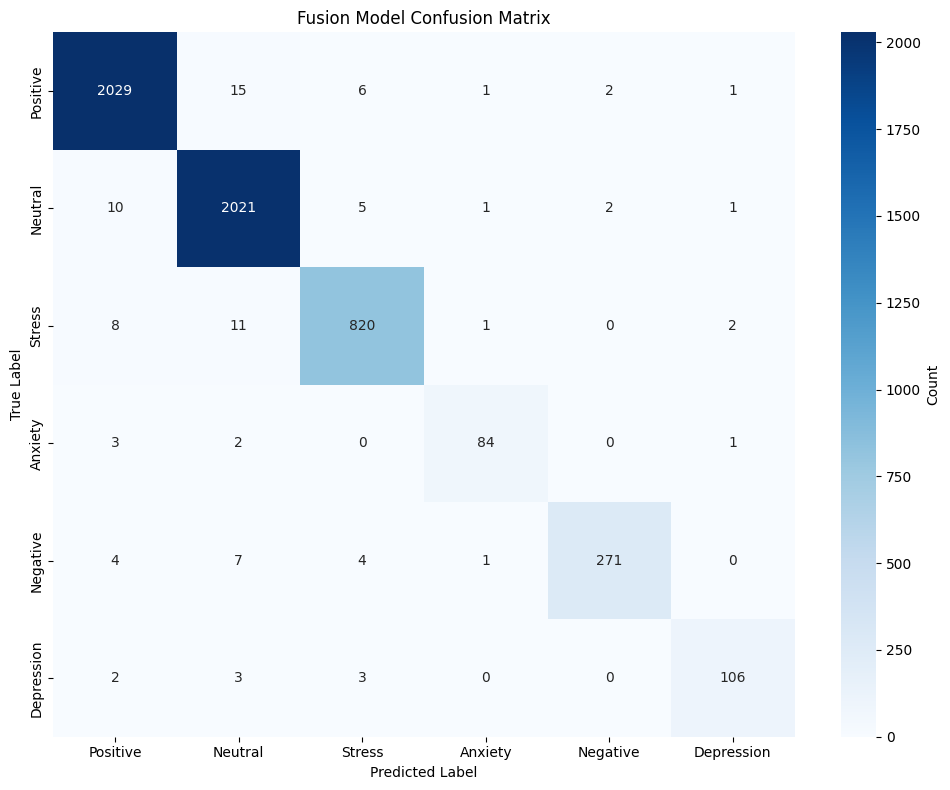

In [16]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Fusion Model Confusion Matrix')
plt.tight_layout()
plt.savefig('../models/fusion_confusion_matrix.png', dpi=150)
plt.show()

# evaluate_scenario is defined in the next cell, below
print("See evaluation scenarios below.")

In [17]:
def evaluate_scenario(X_text, X_audio, X_face, y_true, name):
    X = np.concatenate([X_text, X_audio, X_face], axis=1)
    yp = np.argmax(model.predict(X, verbose=0), axis=1)
    acc = accuracy_score(y_true, yp)
    f1 = f1_score(y_true, yp, average='weighted')
    print(f'{name}: Acc={acc:.4f}, F1={f1:.4f}')
    return acc, f1

In [18]:
def evaluate_scenario(X_text, X_audio, X_face, y_true, name):
    X = np.concatenate([X_text, X_audio, X_face], axis=1)
    logits = model.predict(X, verbose=0)
    yp = np.argmax(logits, axis=1)
    acc = accuracy_score(y_true, yp)
    f1 = f1_score(y_true, yp, average='weighted')
    print(f'{name}: Acc={acc:.4f}, F1={f1:.4f}')
    return acc, f1

print('='*60)
print('EVALUATION SCENARIOS')
print('='*60+chr(10))

y_true = np.argmax(y_test, axis=1)
Xt = X_test[:, :6]
Xa = X_test[:, 6:12]
Xf = X_test[:, 12:18]

evaluate_scenario(Xt, Xa, Xf, y_true, 'A: All 3 modalities')

u = np.ones((len(X_test), 6)) / 6.0
evaluate_scenario(Xt, u, u, y_true, 'B: Text only')
evaluate_scenario(Xt, Xa, u, y_true, 'C: Text+audio')
evaluate_scenario(Xt, u, Xf, y_true, 'D: Text+face')

EVALUATION SCENARIOS



A: All 3 modalities: Acc=0.9823, F1=0.9823


B: Text only: Acc=0.9685, F1=0.9680


C: Text+audio: Acc=0.9766, F1=0.9765


D: Text+face: Acc=0.9775, F1=0.9774


(0.9775198083655795, 0.9774256603453418)

In [19]:
model.save('../models/fusion_model.h5')
print('Fusion model saved to: ../models/fusion_model.h5')

Fusion model saved to: ../models/fusion_model.h5


In [20]:
from tensorflow.keras.models import load_model
loaded = load_model('../models/fusion_model.h5')
test_sample = np.array([generate_training_sample(0, 'agree')])
logits = loaded.predict(test_sample, verbose=0)[0]
# Apply softmax for probabilities
probs = np.exp(logits) / np.sum(np.exp(logits))
pc = CLASS_NAMES[np.argmax(probs)]
print(f'Sanity check: predicted {pc} with confidence {np.max(probs):.4f}')


Sanity check: predicted Positive with confidence 0.9586


In [21]:
print('Done! Fusion model training complete.')

Done! Fusion model training complete.
